# Home Credit Default Risk
### Author: Siqi Wang
### Dataset: Home Credit Group (Kaggle)
### Goal: Predict default risk using demographic, financial, and behavioral features.
### Date: October 2025

## 1. Introduction

Many people struggle to get loans due to insufficient or non-existent credit histories. And, unfortunately, this population is often taken advantage of by untrustworthy lenders.

Home Credit Group

Home Credit strives to broaden financial inclusion for the unbanked population by providing a positive and safe borrowing experience. In order to make sure this underserved population has a positive loan experience, Home Credit makes use of a variety of alternative data--including telco and transactional information--to predict their clients' repayment abilities.

While Home Credit is currently using various statistical and machine learning methods to make these predictions, they're challenging Kagglers to help them unlock the full potential of their data. Doing so will ensure that clients capable of repayment are not rejected and that loans are given with a principal, maturity, and repayment calendar that will empower their clients to be successful.

https://www.kaggle.com/c/home-credit-default-risk/

## 2. Data Loading and Overview

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
pd.set_option('display.max_columns', None)

In [34]:
app_train = pd.read_csv("./home-credit-default-risk/application_train.csv")
app_test = pd.read_csv("./home-credit-default-risk/application_test.csv")
bureau = pd.read_csv("./home-credit-default-risk/bureau.csv")
bureau_balance = pd.read_csv("./home-credit-default-risk/bureau_balance.csv")
prev_app = pd.read_csv("./home-credit-default-risk/previous_application.csv")
installments = pd.read_csv("./home-credit-default-risk/installments_payments.csv")
credit_card = pd.read_csv("./home-credit-default-risk/credit_card_balance.csv")
pos_cash = pd.read_csv("./home-credit-default-risk/POS_CASH_balance.csv")

print(app_train.shape, app_test.shape)
app_train.head()

(307511, 122) (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### Missing Values

In [35]:
nan_count = app_train.isna().sum().sort_values(ascending=False)
print(nan_count.head(20)) 

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64


### Boxplot for EXT_SOURCE

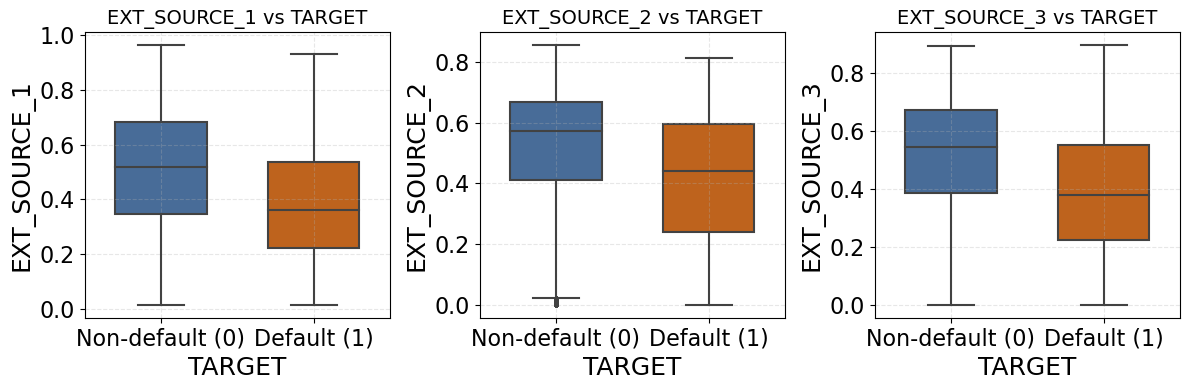

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(
        x='TARGET',
        y=col,
        data=app_train,
        palette=['#3B6BA5', '#D95F02'],
        width=0.6,
        fliersize=2  # 异常点大小
    )
    plt.title(f'{col} vs TARGET', fontsize=14)
    plt.xlabel('TARGET', fontsize=18)
    plt.ylabel(col, fontsize=18)
    plt.xticks([0, 1], ['Non-default (0)', 'Default (1)'], fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("EXT_SOURCE_boxplot.pdf", bbox_inches='tight', dpi=300)
# 显示图像
plt.show()


## 3. Data Cleaning

In [4]:
import numpy as np
import pandas as pd

def safe_div(a, b):
    out = np.divide(a, b, out=np.zeros_like(a, dtype=float), where=(b!=0))
    return out

# --- BUREAU + BUREAU_BALANCE ---
# 1) bureau 基础聚合 + 计数
buro = bureau.copy()
buro['IS_ACTIVE'] = (buro['CREDIT_ACTIVE'] == 'Active').astype('int8')
buro['IS_CLOSED'] = (buro['CREDIT_ACTIVE'] == 'Closed').astype('int8')

buro_agg = buro.groupby('SK_ID_CURR').agg(
    BURO_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BURO_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BURO_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BURO_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BURO_AMT_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BURO_AMT_CREDIT_SUM_MAX=('AMT_CREDIT_SUM', 'max'),
    BURO_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BURO_AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BURO_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE','mean'),
    BURO_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE','max'),
    BURO_CREDIT_DAY_OVERDUE_SUM=('CREDIT_DAY_OVERDUE','sum'),
    BURO_N_LOANS=('SK_ID_BUREAU','count'),
    BURO_N_ACTIVE=('IS_ACTIVE','sum'),
    BURO_N_CLOSED=('IS_CLOSED','sum')
).reset_index()

# 2) bureau_balance：状态占比 + “最近值” + “样本数”
bb = bureau_balance[['SK_ID_BUREAU','MONTHS_BALANCE','STATUS']].copy()
# 状态 one-hot 占比（对每个 SK_ID_BUREAU）
bb_stat = (bb
    .pivot_table(index='SK_ID_BUREAU', columns='STATUS', values='MONTHS_BALANCE', aggfunc='count')
    .fillna(0))
bb_stat = bb_stat.div(bb_stat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
bb_stat.columns = [f'BB_PCT_STATUS_{c}' for c in bb_stat.columns]
bb_cnt = bb.groupby('SK_ID_BUREAU').size().rename('BB_N_ROWS')

# 最近月份（最大 MONTHS_BALANCE）的状态是否逾期（>0）
idx_recent = bb.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].idxmax()
bb_recent = bb.loc[idx_recent, ['SK_ID_BUREAU','STATUS']].copy()
bb_recent['BB_RECENT_DPD_FLAG'] = bb_recent['STATUS'].isin(['1','2','3','4','5']).astype('int8')
bb_recent = bb_recent.drop(columns='STATUS').set_index('SK_ID_BUREAU')

bb_feat = (pd.concat([bb_stat, bb_cnt, bb_recent], axis=1)
           .reset_index())

# 汇回到 bureau，再到客户
buro_min = buro[['SK_ID_BUREAU','SK_ID_CURR']].copy()
bb_join = buro_min.merge(bb_feat, on='SK_ID_BUREAU', how='left')\
                  .drop(columns='SK_ID_BUREAU')
bb_agg = bb_join.groupby('SK_ID_CURR').agg(['mean','max','sum'])
bb_agg.columns = ['BB_' + c[0] + '_' + c[1].upper() for c in bb_agg.columns]
bb_agg = bb_agg.reset_index()

# --- INSTALLMENTS（分期） ---
ip = installments[['SK_ID_CURR','DAYS_INSTALMENT','DAYS_ENTRY_PAYMENT',
                   'AMT_INSTALMENT','AMT_PAYMENT']].copy()
ip['DPD'] = (ip['DAYS_ENTRY_PAYMENT'] - ip['DAYS_INSTALMENT']).clip(lower=0)
ip['DBD'] = (ip['DAYS_INSTALMENT'] - ip['DAYS_ENTRY_PAYMENT']).clip(lower=0)
ip['PAY_RATIO'] = safe_div(ip['AMT_PAYMENT'].values, ip['AMT_INSTALMENT'].replace(0, np.nan).values)

ip_agg = ip.groupby('SK_ID_CURR').agg(
    IP_DPD_MEAN=('DPD','mean'),
    IP_DPD_MAX=('DPD','max'),
    IP_DPD_SUM=('DPD','sum'),
    IP_DBD_MEAN=('DBD','mean'),
    IP_DBD_MAX=('DBD','max'),
    IP_DBD_SUM=('DBD','sum'),
    IP_PAY_RATIO_MEAN=('PAY_RATIO','mean'),
    IP_PAY_RATIO_MAX=('PAY_RATIO','max'),
    IP_N_PAYMENTS=('DPD','size'),
    IP_OVERDUE_RATE=('DPD', lambda s: (s>0).mean())
).reset_index()

# --- PREVIOUS APPLICATION（历史申请） ---
pa = prev_app[['SK_ID_CURR','NAME_CONTRACT_STATUS','AMT_CREDIT','AMT_ANNUITY',
               'DAYS_DECISION','CNT_PAYMENT','DAYS_FIRST_DRAWING','DAYS_FIRST_DUE',
               'DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']].copy()

pa = pa.replace({'DAYS_FIRST_DRAWING': {365243: np.nan},
                 'DAYS_FIRST_DUE': {365243: np.nan},
                 'DAYS_LAST_DUE_1ST_VERSION': {365243: np.nan},
                 'DAYS_LAST_DUE': {365243: np.nan},
                 'DAYS_TERMINATION': {365243: np.nan}})

pa['IS_APPROVED'] = (pa['NAME_CONTRACT_STATUS']=='Approved').astype('int8')
pa['IS_REFUSED']  = (pa['NAME_CONTRACT_STATUS']=='Refused').astype('int8')

g = pa.groupby('SK_ID_CURR')
pa_agg = pd.concat([
    g['AMT_CREDIT'].agg(['mean','max','min']).add_prefix('PA_CREDIT_'),
    g['AMT_ANNUITY'].agg(['mean','max']).add_prefix('PA_ANNUITY_'),
    g['CNT_PAYMENT'].agg(['mean','max']).add_prefix('PA_CNTPAY_'),
    g['IS_APPROVED'].mean().rename('PA_APPROVED_RATE'),
    g['IS_REFUSED'].mean().rename('PA_REFUSED_RATE'),
    g['DAYS_DECISION'].agg(['mean','min']).add_prefix('PA_DECISION_'),
    g['DAYS_DECISION'].min().rename('PA_LAST_DECISION_DAYS')  # 最近期（最接近0，数值最小）
], axis=1).reset_index()

# --- CREDIT CARD（信用卡） ---
cc = credit_card[['SK_ID_CURR','MONTHS_BALANCE','AMT_BALANCE',
                  'AMT_CREDIT_LIMIT_ACTUAL','AMT_DRAWINGS_CURRENT',
                  'AMT_PAYMENT_TOTAL_CURRENT','SK_DPD']].copy()
cc['UTIL'] = safe_div(cc['AMT_BALANCE'].values, (cc['AMT_CREDIT_LIMIT_ACTUAL'].values + 1e-6))

def recent_mean(df, n, key, col, name):
    return (df[df['MONTHS_BALANCE']>=-n]
            .groupby(key)[col].mean().rename(name).reset_index())

cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_BAL_MEAN=('AMT_BALANCE','mean'),
    CC_BAL_MAX=('AMT_BALANCE','max'),
    CC_LIMIT_MEAN=('AMT_CREDIT_LIMIT_ACTUAL','mean'),
    CC_LIMIT_MAX=('AMT_CREDIT_LIMIT_ACTUAL','max'),
    CC_DRAW_MEAN=('AMT_DRAWINGS_CURRENT','mean'),
    CC_DRAW_SUM=('AMT_DRAWINGS_CURRENT','sum'),
    CC_PAY_MEAN=('AMT_PAYMENT_TOTAL_CURRENT','mean'),
    CC_PAY_SUM=('AMT_PAYMENT_TOTAL_CURRENT','sum'),
    CC_DPD_MEAN=('SK_DPD','mean'),
    CC_DPD_MAX=('SK_DPD','max'),
    CC_N_ROWS=('SK_DPD','size')
).reset_index()
cc_agg['CC_UTILIZATION'] = safe_div(cc_agg['CC_BAL_MEAN'].values, (cc_agg['CC_LIMIT_MEAN'].values + 1e-6))

# 最近窗口
for n in (3,6,12):
    cc_agg = cc_agg.merge(recent_mean(cc, n, 'SK_ID_CURR','UTIL', f'CC_UTIL_{n}M'), on='SK_ID_CURR', how='left')
    cc_agg = cc_agg.merge(recent_mean(cc, n, 'SK_ID_CURR','SK_DPD', f'CC_DPD_{n}M'), on='SK_ID_CURR', how='left')

# --- POS_CASH ---
pos = pos_cash[['SK_ID_CURR','MONTHS_BALANCE','CNT_INSTALMENT_FUTURE','SK_DPD']].copy()
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_MONTHS_MAX=('MONTHS_BALANCE','max'),
    POS_MONTHS_MIN=('MONTHS_BALANCE','min'),
    POS_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE','mean'),
    POS_FUTURE_MAX=('CNT_INSTALMENT_FUTURE','max'),
    POS_DPD_MEAN=('SK_DPD','mean'),
    POS_DPD_MAX=('SK_DPD','max'),
    POS_OVERDUE_RATE=('SK_DPD', lambda s: (s>0).mean()),
    POS_N_ROWS=('SK_DPD','size')
).reset_index()

def recent_val(df, n, key, col, name):
    recent = df[df['MONTHS_BALANCE']>=-n]
    idx = recent.groupby(key)['MONTHS_BALANCE'].idxmax()
    return recent.loc[idx, [key, col]].rename(columns={col: name})

for n in (3,6):
    pos_agg = pos_agg.merge(recent_mean(pos, n, 'SK_ID_CURR','CNT_INSTALMENT_FUTURE', f'POS_FUTURE_{n}M'), on='SK_ID_CURR', how='left')
    tmp_last = recent_val(pos, n, 'SK_ID_CURR','SK_DPD', f'POS_DPD_LAST_{n}M')
    pos_agg = pos_agg.merge(tmp_last, on='SK_ID_CURR', how='left')

# === 一次性 merge 到 app ===
def merge_all(base):
    out = (base
        .merge(buro_agg, on='SK_ID_CURR', how='left')
        .merge(bb_agg,   on='SK_ID_CURR', how='left')
        .merge(ip_agg,   on='SK_ID_CURR', how='left')
        .merge(pa_agg,   on='SK_ID_CURR', how='left')
        .merge(cc_agg,   on='SK_ID_CURR', how='left')
        .merge(pos_agg,  on='SK_ID_CURR', how='left'))
    return out

app_train = merge_all(app_train)
app_test  = merge_all(app_test)

# 全量填 0（树模型安全），或者后面再用 train 中位数统一填充
fill_cols = app_train.columns.difference(['TARGET','SK_ID_CURR'])
app_train[fill_cols] = app_train[fill_cols].fillna(0)
app_test[fill_cols]  = app_test[fill_cols].fillna(0)


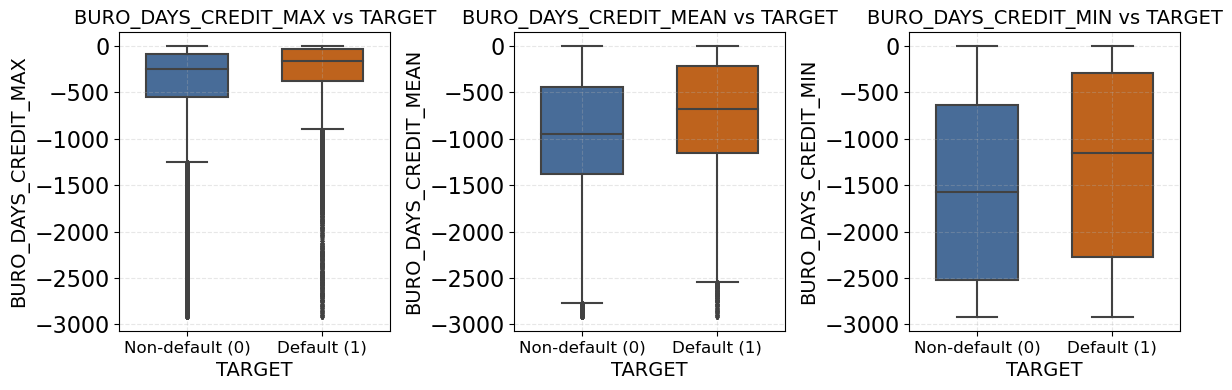

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
for i, col in enumerate(['BURO_DAYS_CREDIT_MAX', 'BURO_DAYS_CREDIT_MEAN', 'BURO_DAYS_CREDIT_MIN'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(
        x='TARGET',
        y=col,
        data=app_train,
        palette=['#3B6BA5', '#D95F02'],
        width=0.6,
        fliersize=2  # 异常点大小
    )
    plt.title(f'{col} vs TARGET', fontsize=14)
    plt.xlabel('TARGET', fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.xticks([0, 1], ['Non-default (0)', 'Default (1)'], fontsize=12)
    plt.yticks(fontsize=16)
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig("EXT_SOURCE_boxplot.pdf", bbox_inches='tight', dpi=300)
# 显示图像
plt.show()


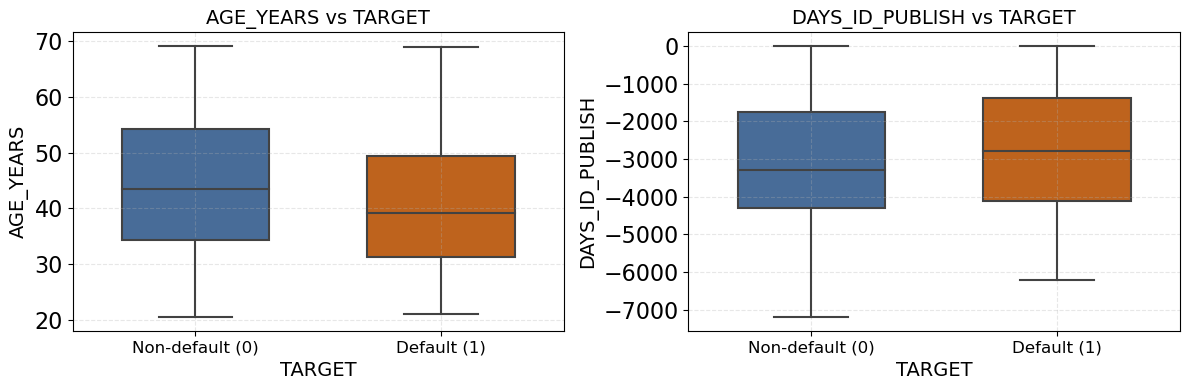

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BURO_DAYS_CREDIT_MEAN,BURO_DAYS_CREDIT_MAX,BURO_DAYS_CREDIT_MIN,BURO_AMT_CREDIT_SUM_MEAN,BURO_AMT_CREDIT_SUM_SUM,BURO_AMT_CREDIT_SUM_MAX,BURO_AMT_CREDIT_SUM_DEBT_MEAN,BURO_AMT_CREDIT_SUM_DEBT_SUM,BURO_CREDIT_DAY_OVERDUE_MEAN,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_SUM,BURO_N_LOANS,BURO_N_ACTIVE,BURO_N_CLOSED,BB_BB_PCT_STATUS_0_MEAN,BB_BB_PCT_STATUS_0_MAX,BB_BB_PCT_STATUS_0_SUM,BB_BB_PCT_STATUS_1_MEAN,BB_BB_PCT_STATUS_1_MAX,BB_BB_PCT_STATUS_1_SUM,BB_BB_PCT_STATUS_2_MEAN,BB_BB_PCT_STATUS_2_MAX,BB_BB_PCT_STATUS_2_SUM,BB_BB_PCT_STATUS_3_MEAN,BB_BB_PCT_STATUS_3_MAX,BB_BB_PCT_STATUS_3_SUM,BB_BB_PCT_STATUS_4_MEAN,BB_BB_PCT_STATUS_4_MAX,BB_BB_PCT_STATUS_4_SUM,BB_BB_PCT_STATUS_5_MEAN,BB_BB_PCT_STATUS_5_MAX,BB_BB_PCT_STATUS_5_SUM,BB_BB_PCT_STATUS_C_MEAN,BB_BB_PCT_STATUS_C_MAX,BB_BB_PCT_STATUS_C_SUM,BB_BB_PCT_STATUS_X_MEAN,BB_BB_PCT_STATUS_X_MAX,BB_BB_PCT_STATUS_X_SUM,BB_BB_N_ROWS_MEAN,BB_BB_N_ROWS_MAX,BB_BB_N_ROWS_SUM,BB_BB_RECENT_DPD_FLAG_MEAN,BB_BB_RECENT_DPD_FLAG_MAX,BB_BB_RECENT_DPD_FLAG_SUM,IP_DPD_MEAN,IP_DPD_MAX,IP_DPD_SUM,IP_DBD_MEAN,IP_DBD_MAX,IP_DBD_SUM,IP_PAY_RATIO_MEAN,IP_PAY_RATIO_MAX,IP_N_PAYMENTS,IP_OVERDUE_RATE,PA_CREDIT_mean,PA_CREDIT_max,PA_CREDIT_min,PA_ANNUITY_mean,PA_ANNUITY_max,PA_CNTPAY_mean,PA_CNTPAY_max,PA_APPROVED_RATE,PA_REFUSED_RATE,PA_DECISION_mean,PA_DECISION_min,PA_LAST_DECISION_DAYS,CC_BAL_MEAN,CC_BAL_MAX,CC_LIMIT_MEAN,CC_LIMIT_MAX,CC_DRAW_MEAN,CC_DRAW_SUM,CC_PAY_MEAN,CC_PAY_SUM,CC_DPD_MEAN,CC_DPD_MAX,CC_N_ROWS,CC_UTILIZATION,CC_UTIL_3M,CC_DPD_3M,CC_UTIL_6M,CC_DPD_6M,CC_UTIL_12M,CC_DPD_12M,POS_MONTHS_MAX,POS_MONTHS_MIN,POS_FUTURE_MEAN,POS_FUTURE_MAX,POS_DPD_MEAN,POS_DPD_MAX,POS_OVERDUE_RATE,POS_N_ROWS,POS_FUTURE_3M,POS_DPD_LAST_3M,POS_FUTURE_6M,POS_DPD_LAST_6M,DAYS_EMPLOYED_CLEAN,INCOME_CREDIT_RATIO,ANNUITY_INCOME_RATIO,AGE,EMPLOYED_YE

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
app_train['AGE_YEARS'] = (-app_train['DAYS_BIRTH']) / 365.0
for i, col in enumerate(['AGE_YEARS', 'DAYS_ID_PUBLISH'], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(
        x='TARGET',
        y=col,
        data=app_train,
        palette=['#3B6BA5', '#D95F02'],
        width=0.6,
        fliersize=2  # 异常点大小
    )
    plt.title(f'{col} vs TARGET', fontsize=14)
    plt.xlabel('TARGET', fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.xticks([0, 1], ['Non-default (0)', 'Default (1)'], fontsize=12)
    plt.yticks(fontsize=16)
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig("EXT_SOURCE_boxplot.pdf", bbox_inches='tight', dpi=300)
# 显示图像
plt.show()
app_train.drop(['AGE_YEARS'], axis=1)

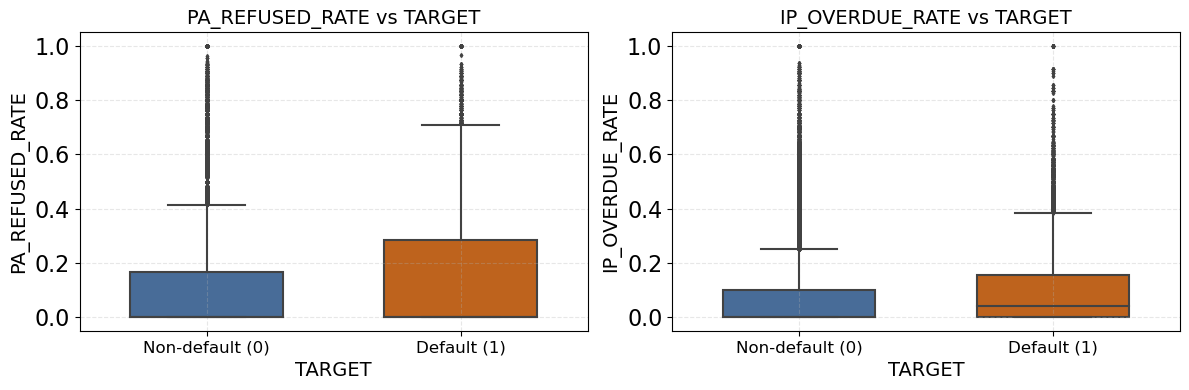

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
for i, col in enumerate(['PA_REFUSED_RATE', 'IP_OVERDUE_RATE',], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(
        x='TARGET',
        y=col,
        data=app_train,
        palette=['#3B6BA5', '#D95F02'],
        width=0.6,
        fliersize=2  # 异常点大小
    )
    plt.title(f'{col} vs TARGET', fontsize=14)
    plt.xlabel('TARGET', fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.xticks([0, 1], ['Non-default (0)', 'Default (1)'], fontsize=12)
    plt.yticks(fontsize=16)
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig("EXT_SOURCE_boxplot.pdf", bbox_inches='tight', dpi=300)
# 显示图像
plt.show()


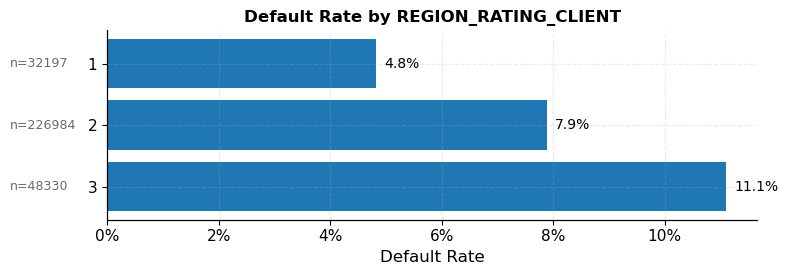

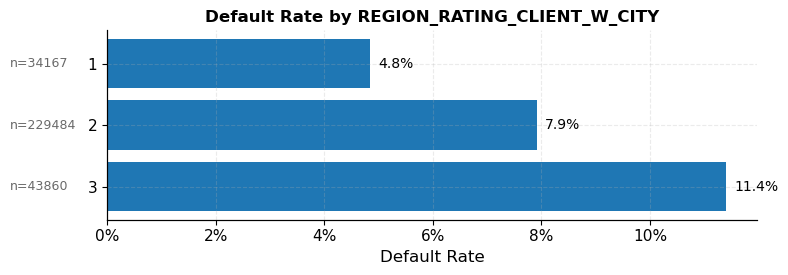

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------- 全局样式（可按需要微调）---------
plt.rcParams.update({
    "figure.figsize": (6.5, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

def pct(y, pos):
    return f"{y*100:.0f}%"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_default_rate_by_cat(df, col, target='TARGET', top_k=12, show_counts=True):
    s = df[col].copy()
    s = s.fillna("Missing").astype(str)

    # 统计每类样本数
    counts = s.value_counts()

    # 选取Top-K，其余合并为Other
    top = counts.head(top_k)
    mask_top = s.isin(top.index)
    s_reduced = s.where(mask_top, other="Other")

    # 重新计算（含 Other）
    tmp = pd.DataFrame({col: s_reduced, target: df[target].values})
    grp = tmp.groupby(col).agg(
        samples=(target, 'size'),
        default_rate=(target, 'mean')
    )

    # 按违约率排序显示（也可改为按 samples 排序）
    grp = grp.sort_values('default_rate', ascending=False)

    # 绘图：水平条形图
    fig, ax1 = plt.subplots(figsize=(8, 0.45*len(grp) + 1.5))
    y_pos = np.arange(len(grp))
    bars = ax1.barh(y_pos, grp['default_rate'].values)

    # 轴与标题
    ax1.set_yticks(y_pos, labels=grp.index)
    ax1.set_xlabel('Default Rate')
    ax1.set_title(f'Default Rate by {col}')

    # 百分比格式
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

    # 在条形右端标注百分比
    for y, v in zip(y_pos, grp['default_rate'].values):
        ax1.annotate(f"{v*100:.1f}%", xy=(v, y),
                     xytext=(6, 0), textcoords='offset points',
                     va='center', fontsize=10)

    # 网格与边框
    ax1.grid(axis='x', linestyle='--', alpha=0.25)
    for spine in ['top', 'right']:
        ax1.spines[spine].set_visible(False)

    # 副轴显示样本数（可关）
    if show_counts:
        ax2 = ax1.twiny()
        ax2.set_xlim(ax1.get_xlim())
        # 用次坐标轴显示样本数文本
        for y, n in zip(y_pos, grp['samples'].values):
            ax1.annotate(f"n={int(n)}", xy=(0, y),
                         xytext=(-70, 0), textcoords='offset points',
                         va='center', ha='left', fontsize=9, color='dimgray')
        # 隐藏副轴刻度线
        ax2.set_xticks([])
        ax2.set_xlabel('')

    plt.tight_layout()
    plt.show()


# --------- 绘图调用 ---------
for col in ["REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY"]:
    plot_default_rate_by_cat(app_train, col)


In [19]:
import numpy as np

def safe_div(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.zeros_like(num, dtype=float)
    np.divide(num, den, out=out, where=(den != 0) & np.isfinite(den))
    return out

def add_app_features(df):
    # 不删行：将异常性别标为缺失（或单独类别）
    # 可选做法1：缺失
    df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)
    # 可选做法2（如果后面要映射成0/1）：把 XNA 当作 0 或额外类别

    # 统一处理 DAYS_EMPLOYED 的哨兵
    df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # 比例特征：使用安全除法
    df['INCOME_CREDIT_RATIO']  = safe_div(df['AMT_INCOME_TOTAL'], df['AMT_CREDIT'])
    df['ANNUITY_INCOME_RATIO'] = safe_div(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])

    # 年龄/工龄（年）
    df['AGE']            = -df['DAYS_BIRTH'] / 365.0
    df['EMPLOYED_YEARS'] = -df['DAYS_EMPLOYED_CLEAN'] / 365.0

    # （可选）加几个常用稳健特征
    df['CREDIT_TERM'] = safe_div(df['AMT_ANNUITY'], df['AMT_CREDIT'])              # 还款额/额度 ~ 期限 proxy
    df['PAYMENT_RATE'] = safe_div(df['AMT_ANNUITY'], df['AMT_CREDIT'])             # 与上等价，后续可二选一
    df['INCOME_PER_PERSON'] = safe_div(df['AMT_INCOME_TOTAL'], (1 + df['CNT_FAM_MEMBERS']))
    df['INCOME_PER_CHILD']  = safe_div(df['AMT_INCOME_TOTAL'], (1 + df['CNT_CHILDREN']))

    # （可选）对数前裁剪，防负数/inf
    df['INCOME_CREDIT_RATIO_LOG'] = np.log1p(np.clip(df['INCOME_CREDIT_RATIO'], 0, None))
    return df

app_train = add_app_features(app_train.copy())
app_test  = add_app_features(app_test.copy())

# 统一缺失填充（树模型直接 0 一般安全；更严谨可用 train 中位数填 test）
fill_cols = [c for c in app_train.columns if c not in ['TARGET','SK_ID_CURR']]
app_train[fill_cols] = app_train[fill_cols].fillna(0)
app_test[fill_cols]  = app_test[fill_cols].fillna(0)


In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# 1) 选择底层列
poly_input_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']

# 用 AGE_YEARS（正值，单位：年）
for df in [app_train, app_test]:
    if 'AGE_YEARS' not in df.columns:
        df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0

# 2) y 备份
y = app_train['TARGET'].copy()

# 3) 仅对 poly 输入做填补（用 train 的统计量）
app_train_sub = app_train[poly_input_cols].copy()
app_test_sub  = app_test[poly_input_cols].copy()

train_median = app_train_sub.median()
app_train_sub = app_train_sub.fillna(train_median)
app_test_sub  = app_test_sub.fillna(train_median)  # 注意：用 train 统计量

# 4) 多项式交互（仅交互，degree=2）
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly.fit(app_train_sub)

train_poly = poly.transform(app_train_sub)
test_poly  = poly.transform(app_test_sub)

poly_cols = [f'POLY__{c}' for c in poly.get_feature_names_out(poly_input_cols)]

poly_train_df = pd.DataFrame(train_poly, columns=poly_cols, index=app_train.index)
poly_test_df  = pd.DataFrame(test_poly,  columns=poly_cols, index=app_test.index)

# 5) 合并回原表
app_train_poly = pd.concat([app_train, poly_train_df], axis=1)
app_test_poly  = pd.concat([app_test,  poly_test_df],  axis=1)

# 6) 列对齐 —— 用“左对齐”保留所有训练特征；test 中缺失列补 0
train_no_target = app_train_poly.drop(columns=['TARGET'])
train_no_target, app_test_poly = train_no_target.align(
    app_test_poly, join='left', axis=1, fill_value=0
)

# 把 TARGET 加回
app_train_poly_aligned = pd.concat([train_no_target, y], axis=1)

# 可选：确保 ID/行数完整
assert 'SK_ID_CURR' in app_train_poly_aligned.columns
assert 'SK_ID_CURR' in app_test_poly.columns
assert app_test_poly['SK_ID_CURR'].nunique() == app_test['SK_ID_CURR'].nunique()

# 如果后续模型用 app_train_poly_aligned
app_test = app_test_poly  # 仅当你后面都以这个 app_test 继续


C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_8600\189456848.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0


In [21]:
# 1) 训练特征集合（以训练集为准）
features = [c for c in app_train_poly_aligned.columns if c not in ['TARGET','SK_ID_CURR']]

# 2) 训练集设计矩阵
X = app_train_poly_aligned[features].copy()

# 3) 测试集严格按训练列 reindex（缺的列会自动补 NaN；多余列被丢弃）
app_test_features = app_test.reindex(columns=features)

# 4) 缺失填充：
#    - 先用 train 的列中位数去填 test（推荐）
#    - train 也可以统一填 0（或中位数），保证和 test 一致
# 只对数值列取中位数
train_median = X.select_dtypes(include=[np.number]).median()

# 然后用中位数去填充，只在数值列上生效
X = X.fillna(train_median)
app_test_features = app_test_features.fillna(train_median)

# 5) 可选：清理 inf（极少见，但稳妥）
X = X.replace([np.inf, -np.inf], 0)
app_test_features = app_test_features.replace([np.inf, -np.inf], 0)

# 6) 目标
y = app_train_poly_aligned['TARGET'].astype(int)


## 3. Exploratory Data Analysis (EDA)

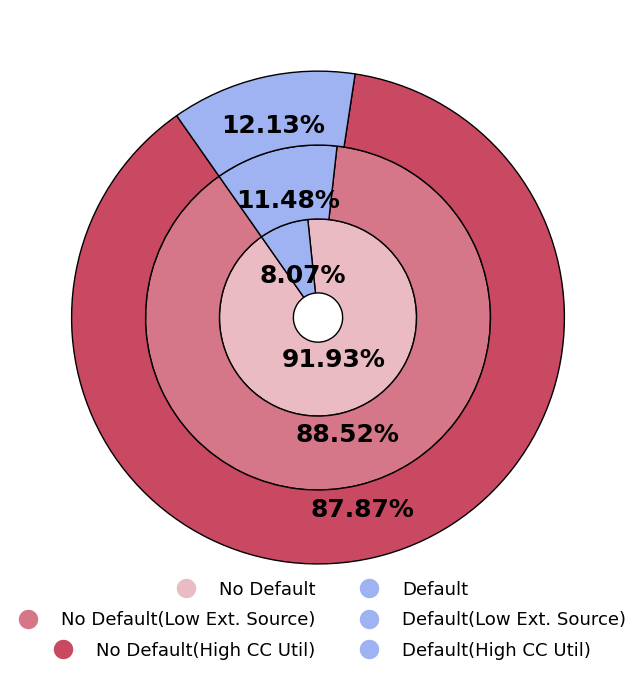

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


# 计算目标变量的分布
target_counts = app_train['TARGET'].value_counts(normalize=True)

# 计算EXT_SOURCE_3的分布
medium_value = app_train['EXT_SOURCE_3'].median()  # 假设medium是EXT_SOURCE_3的中位数
filtered_data = app_train[app_train['EXT_SOURCE_3'] < medium_value]

# 计算筛选后数据中TARGET为0和1的分布
target_counts_filtered_EXT_SOURCE_3 = filtered_data['TARGET'].value_counts(normalize=True)

# 计算CC_UTIL_12M的分布
medium_value = app_train['CC_UTIL_12M'].median()  
cc_util_12m_counts_filtered_data = app_train[app_train['CC_UTIL_12M'] > medium_value]

# 计算筛选后数据中TARGET为0和1的分布
target_counts_filtered_cc_util_12m_counts = cc_util_12m_counts_filtered_data['TARGET'].value_counts(normalize=True)

# 创建甜甜圈图
fig, ax = plt.subplots(figsize=(8, 8))


ax.pie(target_counts, labels=["",""], autopct='%1.2f%%', startangle=125, 
       colors=['#ebbbc4','#9fb2f1'], radius=0.4, wedgeprops=dict(width=0.3, edgecolor='black'), 
       pctdistance=0.45, textprops={'fontsize': 18, 'fontweight': 'bold'})  # 设置宽度为0.3，形成甜甜圈效果


ax.pie(target_counts_filtered_EXT_SOURCE_3, labels=["", ""], autopct='%1.2f%%', startangle=125, 
       colors=['#d67789','#9fb2f1'], radius=0.7, wedgeprops=dict(width=0.3, edgecolor='black'), 
       pctdistance=0.7, textprops={'fontsize': 18, 'fontweight': 'bold'})  # 调整字体大小

ax.pie(target_counts_filtered_cc_util_12m_counts, labels=["", ""], autopct='%1.2f%%', startangle=125, 
       colors=['#c94962','#9fb2f1'],  wedgeprops=dict(width=0.3, edgecolor='black'), 
       pctdistance=0.8, textprops={'fontsize': 18, 'fontweight': 'bold'})  # CC_UTIL_12M

labels1 = ['No Default', 'Default']
colors1 = ['#ebbbc4','#9fb2f1']
handles1 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors1]
first_legend = plt.legend(handles=handles1, labels=labels1, loc="upper center", fontsize=13, bbox_to_anchor=(0.5, 0.1), 
          frameon=False, markerscale=1.5, ncol=2)
ax.add_artist(first_legend) 


labels2 = ['No Default(Low Ext. Source)', 'Default(Low Ext. Source)']
colors2 = ['#d67789','#9fb2f1']
handles2 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors2]
secone_legend = plt.legend(handles=handles2, labels=labels2, loc="upper center", fontsize=13, bbox_to_anchor=(0.5, 0.05), 
          frameon=False, markerscale=1.5, ncol=2)
ax.add_artist(secone_legend) 


labels3 = ['No Default(High CC Util)', 'Default(High CC Util)']
colors3 = ['#c94962','#9fb2f1']
handles3 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors3]
third_legend = plt.legend(handles=handles3, labels=labels3, loc="upper center", fontsize=13, bbox_to_anchor=(0.5, 0), 
          frameon=False, markerscale=1.5, ncol=2)

# ax.add_artist(first_legend) 
# ax.add_artist(secone_legend) 
# ax.add_artist(third_legend) 

plt.savefig("imbalanced_target_distribution.pdf", bbox_inches='tight', dpi=300)
# 显示图像
plt.show()


## 4. Feature Engineering

In [23]:
# 检查并转换类别特征为数值类型
def convert_categorical_features(df):
    # 将分类变量映射为数值型
    df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1}).astype(float)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': 0}).astype(float)
    df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1}).astype(float)
    df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1}).astype(float)
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].map({'Unaccompanied': 0, 'Missing': 0, 'Other_A': 0, 'Other_B': 0, 'Spouse, partner': 1, 'Family': 1, 'Children': 1, 'Group of people': 1}).astype(float)
    df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].map(lambda v: 1.0 if v in {'Working', 'State servant', 'Commercial associate', 'Businessman', 'Pensioner'} else 0.0).astype(float)
    df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map({'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}).astype(float)
    df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].map({'Single / not married': 0, 'Unknown': 0, 'Widow': 1, 'Separated': 1, 'Married': 2, 'Civil marriage': 2}).astype(float)
    df['NAME_HOUSING_TYPE'] = df['NAME_HOUSING_TYPE'].map({'House / apartment': 1, 'Co-op apartment': 1, 'With parents': 0, 'Rented apartment': 0, 'Municipal apartment': 0, 'Office apartment': 0}).astype(float)
    df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].map({'Managers': 2, 'Accountants': 2, 'Core staff': 2, 'High skill tech staff': 2, 'IT staff': 2, 'HR staff': 2, 'Medicine staff': 2, 'Sales staff': 1, 'Drivers': 1, 'Realty agents': 1, 'Secretaries': 1, 'Laborers': 0, 'Low-skill Laborers': 0, 'Cleaning staff': 0, 'Cooking staff': 0, 'Private service staff': 0, 'Waiters/barmen staff': 0, 'Security staff': 0, 'Missing': 0}).astype(float)
    
    def map_org_type(x):
        if x in {'Government', 'School', 'University', 'Security Ministries', 'Police', 'Military', 'Kindergarten'}: return 3
        if x in {'Bank', 'Insurance', 'Telecom', 'Electricity', 'Medicine'}: return 3
        if str(x).startswith(('Industry', 'Trade', 'Construction')): return 2
        if x in {'Business Entity Type 1', 'Business Entity Type 2', 'Business Entity Type 3', 'Services', 'Realtor', 'Restaurant', 'Hotel', 'Transport: type 1', 'Transport: type 2', 'Transport: type 3', 'Transport: type 4', 'Self-employed'}: return 1
        return 0
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(map_org_type).astype(float)
    
    df['WEEKDAY_APPR_PROCESS_START'] = df['WEEKDAY_APPR_PROCESS_START'].map(lambda x: 1.0 if x in ['SATURDAY', 'SUNDAY'] else 0.0)
    df['FONDKAPREMONT_MODE'] = df['FONDKAPREMONT_MODE'].replace(0, 'Missing').map(lambda x: 1.0 if x in ['reg oper account', 'org spec account', 'reg oper spec account'] else 0.0)
    df['HOUSETYPE_MODE'] = df['HOUSETYPE_MODE'].replace(0, 'Missing').map({'terraced house': 1, 'block of flats': 1, 'specific housing': 0, 'Missing': 0}).astype(float)
    df['WALLSMATERIAL_MODE'] = df['WALLSMATERIAL_MODE'].replace(0, 'Missing').map(lambda x: 1.0 if x in ['Stone, brick', 'Block', 'Monolithic'] else 0.0)
    df['EMERGENCYSTATE_MODE'] = df['EMERGENCYSTATE_MODE'].replace(0, 'Missing').map({'No': 0.0, 'Missing': 0.0, 'Yes': 1.0})
    
    return df

# 处理 train 和 test
X = convert_categorical_features(app_train_poly_aligned[features])
T = convert_categorical_features(app_test_features)

# 填充缺失值：用训练集的中位数填充
train_median = X.select_dtypes(include=[np.number]).median()
X = X.fillna(train_median)
T = T.fillna(train_median)

# 目标
y = app_train_poly_aligned['TARGET'].astype(int)


C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_8600\717893061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1}).astype(float)
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_8600\717893061.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': 0}).astype(float)
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_8600\717893061.py:6: SettingWithCopyWarnin

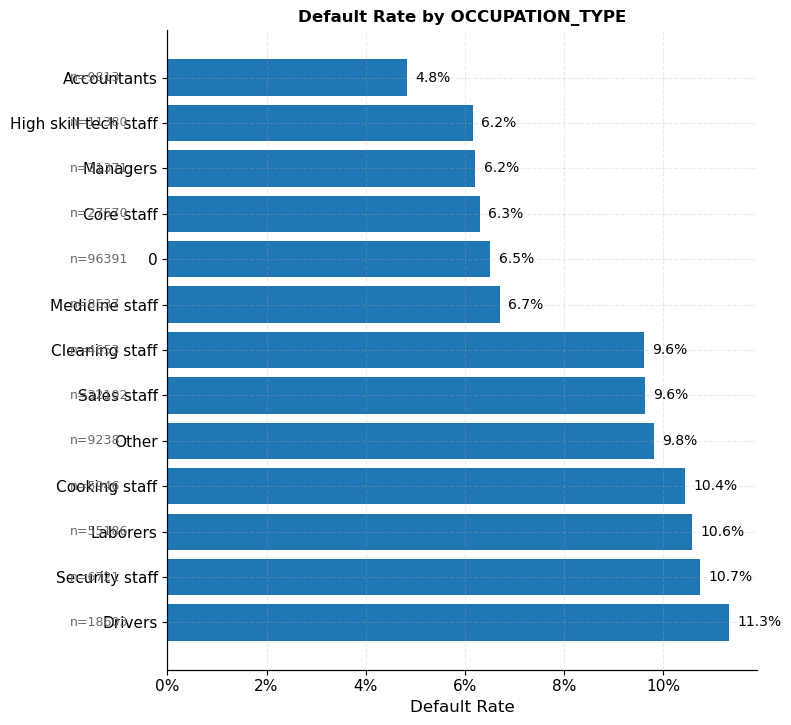

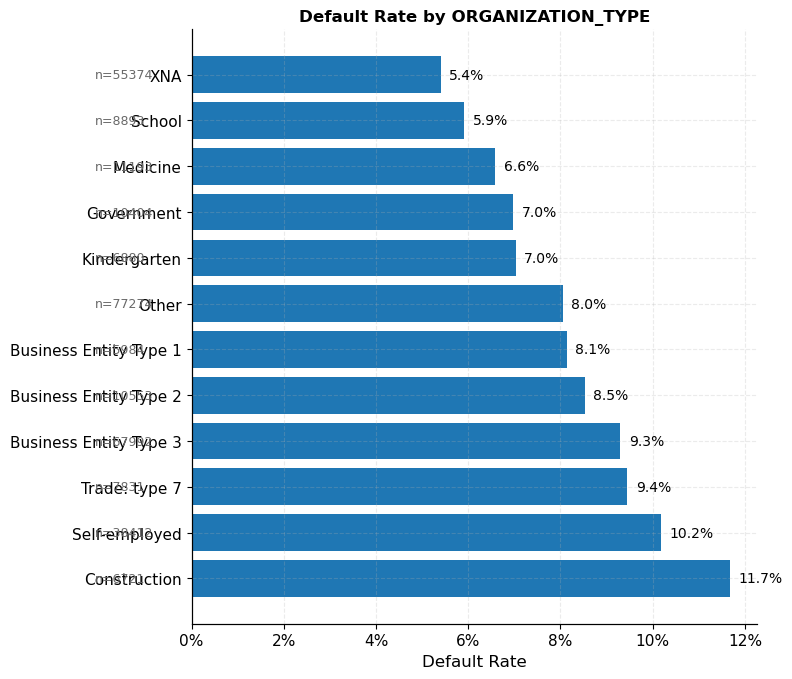

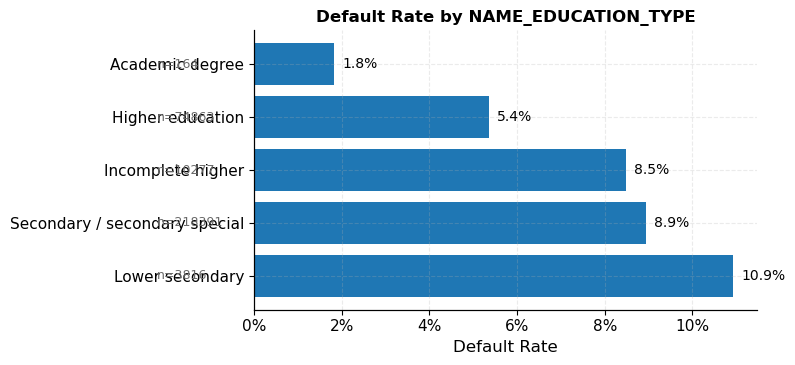

In [31]:
for col in ["OCCUPATION_TYPE", "ORGANIZATION_TYPE", "NAME_EDUCATION_TYPE"]:
    plot_default_rate_by_cat(app_train, col, top_k=12, show_counts=True)


In [32]:
# 仅对数值列计算中位数
train_median = X.select_dtypes(include=[np.number]).median()

# 用训练集中位数填充测试集
T.fillna(train_median, inplace=True)

# 检查测试集中是否缺列
missing_columns = set(X.columns) - set(T.columns)
extra_columns = set(T.columns) - set(X.columns)
print(f"Missing in Test: {missing_columns}")
print(f"Extra in Test: {extra_columns}")

# 最安全的做法：对齐列顺序
T = T.reindex(columns=X.columns)


Missing in Test: set()
Extra in Test: set()


## Feature Heatmap

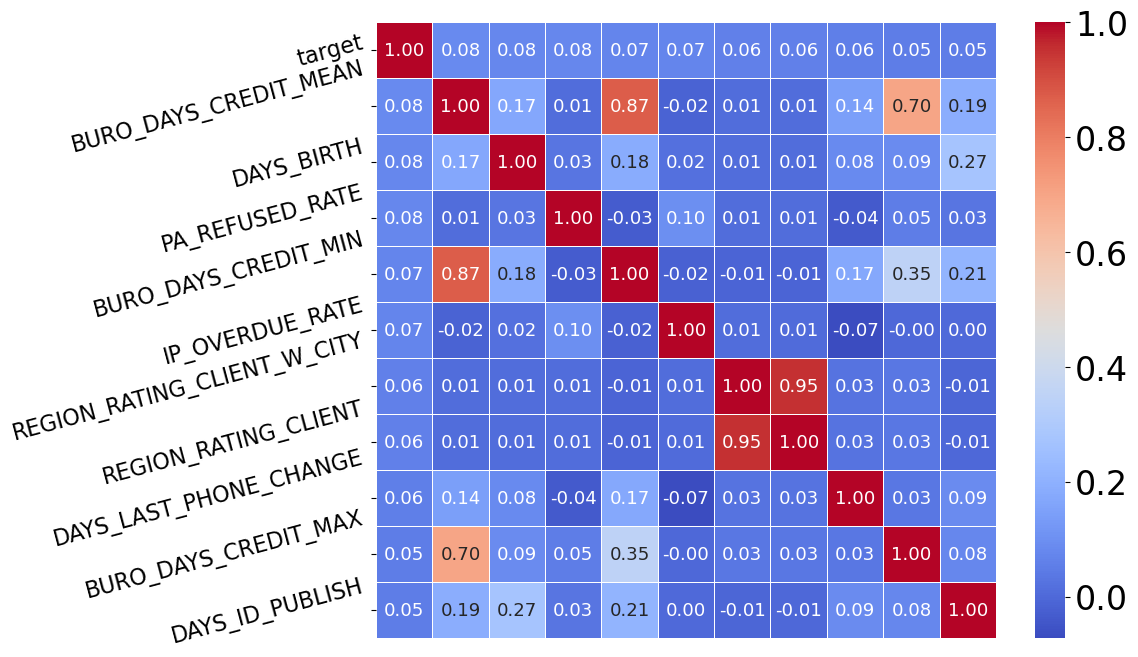

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 获取与 target 相关性较高的特征
X_y = X.copy()
X_y['target'] = y  # 将目标变量合并进来

corr = X_y.corr()  # 计算相关性矩阵
target_corr = corr['target'].sort_values(ascending=False)  # 获取与 target 的相关性



# 选择与 target 相关性前 10 的特征
top_10_features = target_corr[:11].index.tolist()  # 排除 target 自身

# 获取这 10 个特征的相关性子矩阵
top_10_corr_matrix = corr.loc[top_10_features, top_10_features]

# 绘制相关性热力图
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    top_10_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 13},  # 热力图数字字体
#     cbar_kws={'label': 'Correlation'}  # 这里只定义标签
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=24)   # 调节色条刻度字体
# cbar.set_label('Correlation', fontsize=16)  # 调节色条标签字体
ax.xaxis.set_major_locator(plt.NullLocator())
plt.yticks(rotation=15, ha='right', fontsize=42)

# 调整y轴标签字体大小
plt.yticks(fontsize=16)

# 保存热力图
plt.savefig("important_feature_heatmap.pdf", bbox_inches='tight', dpi=300)


In [13]:
top_10_features

['target',
 'BURO_DAYS_CREDIT_MEAN',
 'DAYS_BIRTH',
 'PA_REFUSED_RATE',
 'BURO_DAYS_CREDIT_MIN',
 'IP_OVERDUE_RATE',
 'REGION_RATING_CLIENT_W_CITY',
 'REGION_RATING_CLIENT',
 'DAYS_LAST_PHONE_CHANGE',
 'BURO_DAYS_CREDIT_MAX',
 'DAYS_ID_PUBLISH']

## 6. Model Training and Validation

In [10]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

params = {
    "objective": "binary",
    "n_estimators": 5000,        # 上限；配合 early stopping 自动找 best_iteration_
    "learning_rate": 0.03,
    "max_depth": 10,
    "num_leaves": 30,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.75,
    "bagging_freq": 3,
    "max_bin": 500,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "min_child_samples": 200,
    "min_child_weight": 12,
    "scale_pos_weight":0.1* len(y_train[y_train==0]) / len(y_train[y_train==1]),
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1,
}

clf = LGBMClassifier(**params)

# 早停 + 记录 AUC
clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_names=['train','valid'],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(100)]
)



### Shap plot

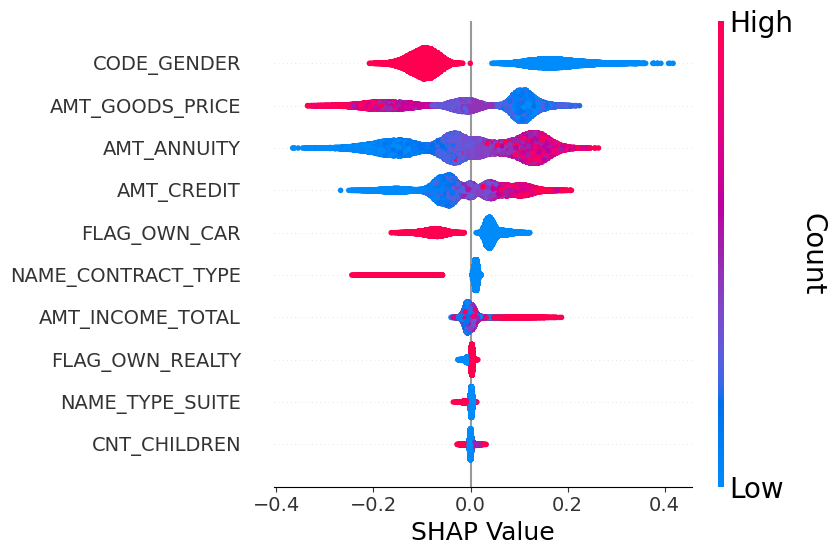

In [403]:
import shap
import matplotlib.pyplot as plt

# 初始化shap
shap.initjs()

# 计算SHAP值
explainer = shap.TreeExplainer(clf)  # clf 是已训练的 LightGBM 模型
shap_values = explainer.shap_values(X_valid)

# 如果是二分类任务，shap_values 是一个 list，取第二类（正类）那一项
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# 获取特征重要性前 N 个
top_n_features = 10  # 可调整显示特征数量
shap_values_top_n = shap_values[:, :top_n_features]
X_valid_top_n = X_valid.iloc[:, :top_n_features]

# 创建 summary plot
shap.summary_plot(shap_values_top_n, X_valid_top_n, feature_names=X_valid_top_n.columns, show=False)

# 获取当前的轴（ax）
ax = plt.gca()

# Adjust x and y ticks specifically for the summary plot
plt.xticks(fontsize=16)  # Set xticks font size
plt.yticks(fontsize=16)  # Set yticks font size

# Set labels font size
plt.xlabel("SHAP Value", fontsize=18)
plt.ylabel("", fontsize=24)

# 修改右侧 colorbar 的字体大小
cbar = ax.get_figure().axes[-1]  # colorbar 在最后一个 axes 中
cbar.tick_params(labelsize=20)   # 调整 colorbar 刻度字体
cbar.set_ylabel('Count', fontsize=20, rotation=270, labelpad=24)  # 加上标签

# 调整 bar 的刻度字体大小
ax.tick_params(axis='x', labelsize=14)  # x-axis tick font size
ax.tick_params(axis='y', labelsize=14)  # y-axis tick font size

# 调整保存的图像大小
plt.savefig("shap_feature_importance.pdf", bbox_inches='tight', dpi=300)
plt.show()


# Conclusion

### Categorical Feature Insights

Several categorical variables show clear differences in default rates:

1. **CODE_GENDER** – More female applicants, yet males tend to have higher default rates.  
2. **REGION_RATING_CLIENT_W_CITY** – Most applicants belong to region rating 2, but those from rating 3 regions have the highest default proportion.  
3. **NAME_EDUCATION_TYPE** – Most clients have *Secondary / Secondary special* education; default rate is highest for *Lower secondary* and lowest for *Academic degree*.  
4. **OCCUPATION_TYPE** – Laborers, drivers, and low-skill workers show higher default rates than managerial or professional occupations.  
5. **REG_CITY_NOT_WORK_CITY** – Clients working outside their registered city are more likely to default.  
6. **ORGANIZATION_TYPE** – Industries such as transport, construction, and restaurants exhibit higher default risk, whereas police, universities, and government institutions show lower rates.  
7. **NAME_CONTRACT_STATUS** (from previous applications) – Clients with past refusals or canceled applications tend to have higher default probabilities.



### Continuous Feature Insights

1. **Correlation Analysis:** Using Phi-K and Pearson correlation analyses, most feature pairs show weak linear relationships, as reflected by the light-colored heatmap in Figure `heatmap_distribution` (left). Exceptions include housing-related variables (e.g., area, floor), which exhibit strong mutual correlations, and significant linear relationships between `AMT_GOODS_PRICE`–`AMT_CREDIT` and `DAYS_EMPLOYED`–`DAYS_BIRTH`.
2. **Key Predictive Features and Distribution Patterns:** Among all continuous features, the `EXT_SOURCE_1/2/3` group demonstrates the highest correlation with the target variable, making them key predictive signals (shown in Figure `EXT_SOURCE_boxplot`). Defaulters generally exhibit lower values for the `EXT_SOURCE` series, while non-defaulters concentrate in higher-value regions. Similarly, defaulters tend to be younger (lower median and quartile ages, as indicated by `DAYS_BIRTH`), have shorter credit histories (`DAYS_CREDIT`), and repay fewer installments (`CNT_INSTALMENT_MATURE_CUM`). Non-defaulters typically show the opposite trends.
3. **Data Quality:** Several `DAYS_*` variables contain sentinel values (e.g., 365243), which should be replaced with NaN to avoid distorting distributions.

---

### Summary of EDA Conclusions

1. The main and auxiliary tables should be merged using the client ID, with careful handling of missing values to retain useful information.
2. Certain categorical features (e.g., occupation, city mismatch, past refusals) exhibit strong discriminatory power and should be included in feature engineering.
3. The `EXT_SOURCE` group provides the strongest correlation with the target and is critical for feature interaction design.
4. Sentinel values (e.g., in `DAYS_*`) must be cleaned, as they distort feature distributions.
5. Most features are weakly correlated, which reduces redundancy; however, some highly collinear groups require monitoring.
6. Given the extreme class imbalance, subsequent modeling should account for weighting, sampling, or metric adjustments.
